# Two Moons: pyflowrs vs nflows

Side-by-side comparison of **pyflowrs** (Rust/Burn via PyO3) and **nflows** (Python/PyTorch)
on the two-moons density estimation benchmark.

Both use the same architecture, data, and training schedule for a fair comparison.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

%matplotlib inline
plt.rcParams.update({"font.size": 12})

## Generate two-moons dataset

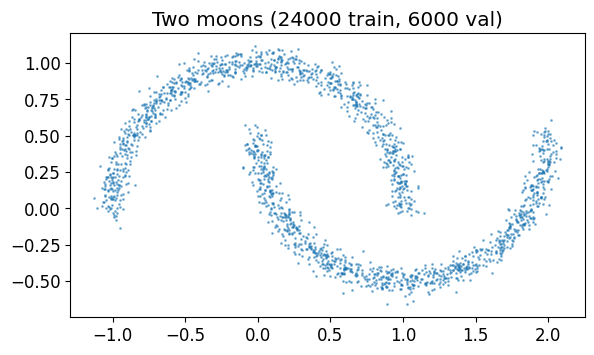

In [2]:
def generate_two_moons(n_samples, noise=0.05, seed=42):
    rng = np.random.default_rng(seed)
    n_half = n_samples // 2
    theta_upper = np.linspace(0, np.pi, n_half)
    x_upper = np.cos(theta_upper)
    y_upper = np.sin(theta_upper)
    theta_lower = np.linspace(0, np.pi, n_samples - n_half)
    x_lower = 1.0 - np.cos(theta_lower)
    y_lower = -np.sin(theta_lower) + 0.5
    x = np.concatenate([x_upper, x_lower])
    y = np.concatenate([y_upper, y_lower])
    data = np.stack([x, y], axis=1).astype(np.float32)
    data += rng.normal(0, noise, size=data.shape).astype(np.float32)
    rng.shuffle(data)
    return data

N_TRAIN, N_VAL = 24000, 6000
data = generate_two_moons(N_TRAIN + N_VAL, noise=0.05, seed=42)
train_data = data[:N_TRAIN]
val_data = data[N_TRAIN:]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(train_data[:2000, 0], train_data[:2000, 1], s=1, alpha=0.5)
ax.set_aspect("equal")
ax.set_title(f"Two moons ({N_TRAIN} train, {N_VAL} val)")
plt.tight_layout()
plt.show()

## Shared config

In [3]:
# Match comparison/config.toml
BATCH_SIZE = 512
NUM_STEPS = 2000       # 100 epochs * 20 batches/epoch
LR = 5e-4
SEED = 42

configs = {
    "MAF":     dict(num_flows=10, hidden_sizes=[256, 256]),
    "NSF":     dict(num_flows=8,  hidden_sizes=[128, 128]),
    "RealNVP": dict(num_flows=8,  hidden_sizes=[128, 128]),
}

print(f"Training: {NUM_STEPS} steps, batch={BATCH_SIZE}, lr={LR}")

Training: 2000 steps, batch=512, lr=0.0005


## Train with pyflowrs (Rust)

In [4]:
import pyflowrs

flowrs_results = {}
flow_classes = {"MAF": pyflowrs.MAF, "NSF": pyflowrs.NSF, "RealNVP": pyflowrs.RealNVP}

for name, cfg in configs.items():
    print(f"\n=== pyflowrs {name} ===")
    flow = flow_classes[name](d_input=2, seed=SEED, **cfg)

    t0 = time.perf_counter()
    history = flow.fit(
        train_data, x_val=val_data,
        num_steps=NUM_STEPS, batch_size=BATCH_SIZE,
        lr=LR, verbose=False, seed=SEED,
    )
    train_time = time.perf_counter() - t0

    # Validation NLL
    val_nll = -flow.log_prob(val_data).mean()

    # Timing: log_prob (forward)
    test_batch = train_data[:BATCH_SIZE]
    for _ in range(10):  # warmup
        flow.log_prob(test_batch)
    t0 = time.perf_counter()
    for _ in range(100):
        flow.log_prob(test_batch)
    fwd_ms = (time.perf_counter() - t0) / 100 * 1000

    # Timing: sample (inverse)
    for _ in range(10):
        flow.sample(BATCH_SIZE)
    t0 = time.perf_counter()
    for _ in range(100):
        flow.sample(BATCH_SIZE)
    inv_ms = (time.perf_counter() - t0) / 100 * 1000

    samples = flow.sample(10000)
    flowrs_results[name] = dict(
        flow=flow, history=history, samples=samples,
        val_nll=val_nll, train_time=train_time,
        fwd_ms=fwd_ms, inv_ms=inv_ms,
    )
    print(f"  Train: {train_time:.1f}s | Val NLL: {val_nll:.4f} | Fwd: {fwd_ms:.2f}ms | Inv: {inv_ms:.2f}ms")


=== pyflowrs MAF ===
  Train: 63.4s | Val NLL: 0.8527 | Fwd: 7.79ms | Inv: 16.61ms

=== pyflowrs NSF ===
  Train: 55.1s | Val NLL: 0.3002 | Fwd: 7.26ms | Inv: 7.76ms

=== pyflowrs RealNVP ===
  Train: 25.9s | Val NLL: 0.3059 | Fwd: 3.37ms | Inv: 3.23ms


## Train with nflows (PyTorch)

In [5]:
import torch
from nflows.distributions import StandardNormal
from nflows.flows import Flow
from nflows.transforms import (
    CompositeTransform,
    MaskedAffineAutoregressiveTransform,
    MaskedPiecewiseRationalQuadraticAutoregressiveTransform,
    RandomPermutation,
    ReversePermutation,
)

def build_nflows(name, cfg, d=2):
    transforms = []
    for i in range(cfg["num_flows"]):
        if name == "NSF":
            transforms.append(
                MaskedPiecewiseRationalQuadraticAutoregressiveTransform(
                    features=d,
                    hidden_features=cfg["hidden_sizes"][0],
                    num_blocks=len(cfg["hidden_sizes"]),
                    num_bins=8, tails="linear", tail_bound=3.0,
                )
            )
        else:  # MAF and RealNVP both use affine autoregressive in nflows
            transforms.append(
                MaskedAffineAutoregressiveTransform(
                    features=d,
                    hidden_features=cfg["hidden_sizes"][0],
                    num_blocks=len(cfg["hidden_sizes"]),
                )
            )
        transforms.append(
            ReversePermutation(features=d) if i % 2 == 1
            else RandomPermutation(features=d)
        )
    return Flow(CompositeTransform(transforms), StandardNormal([d]))


torch.manual_seed(SEED)
train_tensor = torch.tensor(train_data)
val_tensor = torch.tensor(val_data)

nflows_results = {}

for name, cfg in configs.items():
    print(f"\n=== nflows {name} ===")
    model = build_nflows(name, cfg)
    param_count = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {param_count:,}")

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    train_losses, val_losses = [], []

    model.train()
    t0 = time.perf_counter()
    for step in range(1, NUM_STEPS + 1):
        idx = torch.randint(0, len(train_tensor), (BATCH_SIZE,))
        batch = train_tensor[idx]
        optimizer.zero_grad()
        loss = -model.log_prob(batch).mean()
        loss.backward()
        optimizer.step()
        if step % 100 == 0:
            train_losses.append((step, loss.item()))
            with torch.no_grad():
                vl = -model.log_prob(val_tensor).mean().item()
            val_losses.append((step, vl))
    train_time = time.perf_counter() - t0

    model.eval()
    with torch.no_grad():
        val_nll = -model.log_prob(val_tensor).mean().item()

    # Timing
    test_batch = train_tensor[:BATCH_SIZE]
    with torch.no_grad():
        for _ in range(10):
            model.log_prob(test_batch)
        t0 = time.perf_counter()
        for _ in range(100):
            model.log_prob(test_batch)
        fwd_ms = (time.perf_counter() - t0) / 100 * 1000

        for _ in range(10):
            model.sample(BATCH_SIZE)
        t0 = time.perf_counter()
        for _ in range(100):
            model.sample(BATCH_SIZE)
        inv_ms = (time.perf_counter() - t0) / 100 * 1000

    with torch.no_grad():
        samples = model.sample(10000).numpy()

    nflows_results[name] = dict(
        model=model, samples=samples,
        train_losses=train_losses, val_losses=val_losses,
        val_nll=val_nll, train_time=train_time,
        fwd_ms=fwd_ms, inv_ms=inv_ms,
    )
    print(f"  Train: {train_time:.1f}s | Val NLL: {val_nll:.4f} | Fwd: {fwd_ms:.2f}ms | Inv: {inv_ms:.2f}ms")


=== nflows MAF ===
  Parameters: 2,649,640
  Train: 151.4s | Val NLL: 0.3331 | Fwd: 18.60ms | Inv: 37.56ms

=== nflows NSF ===
  Parameters: 578,928
  Train: 63.9s | Val NLL: 0.3580 | Fwd: 11.12ms | Inv: 22.40ms

=== nflows RealNVP ===
  Parameters: 535,584
  Train: 40.6s | Val NLL: 0.3406 | Fwd: 6.60ms | Inv: 12.24ms


## Results comparison

In [6]:
print(f"{'Model':<10} {'Framework':<10} {'Val NLL':>8} {'Train(s)':>9} {'Fwd(ms)':>8} {'Inv(ms)':>8}")
print("-" * 60)
for name in configs:
    fr = flowrs_results[name]
    nr = nflows_results[name]
    print(f"{name:<10} {'pyflowrs':<10} {fr['val_nll']:>8.4f} {fr['train_time']:>9.1f} {fr['fwd_ms']:>8.2f} {fr['inv_ms']:>8.2f}")
    print(f"{'':<10} {'nflows':<10} {nr['val_nll']:>8.4f} {nr['train_time']:>9.1f} {nr['fwd_ms']:>8.2f} {nr['inv_ms']:>8.2f}")
    speedup = nr['train_time'] / fr['train_time']
    print(f"{'':<10} {'speedup':<10} {'':>8} {speedup:>8.1f}x {'':>8} {'':>8}")
    print()

Model      Framework   Val NLL  Train(s)  Fwd(ms)  Inv(ms)
------------------------------------------------------------
MAF        pyflowrs     0.8527      63.4     7.79    16.61
           nflows       0.3331     151.4    18.60    37.56
           speedup                  2.4x                  

NSF        pyflowrs     0.3002      55.1     7.26     7.76
           nflows       0.3580      63.9    11.12    22.40
           speedup                  1.2x                  

RealNVP    pyflowrs     0.3059      25.9     3.37     3.23
           nflows       0.3406      40.6     6.60    12.24
           speedup                  1.6x                  



## Training curves

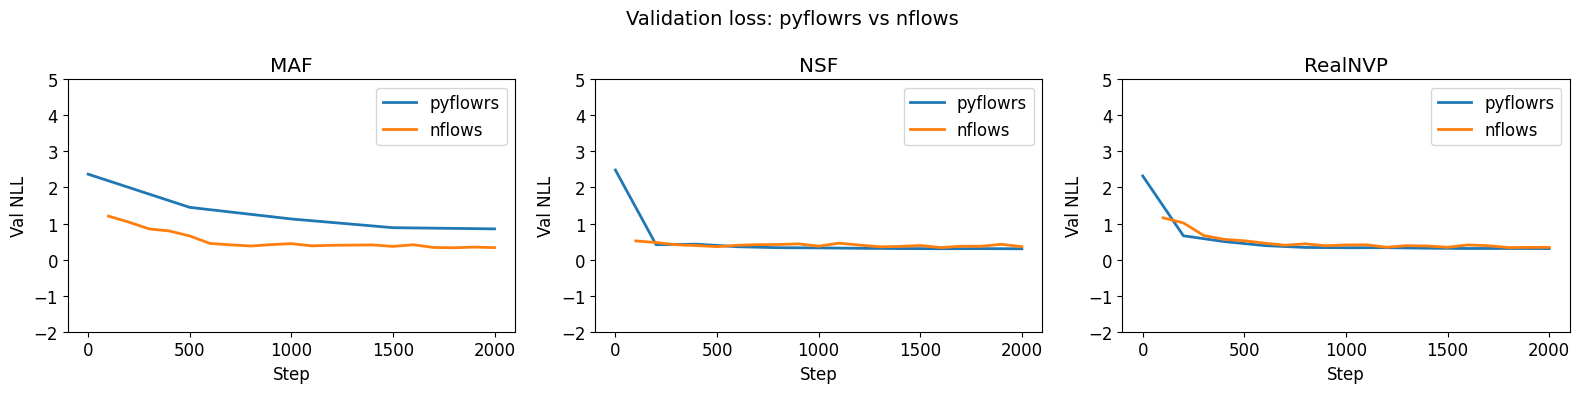

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, name in zip(axes, configs):
    fr = flowrs_results[name]
    nr = nflows_results[name]

    ax.plot(fr["history"].steps, fr["history"].val_loss,
            label="pyflowrs", color="C0", lw=2)
    nf_steps = [s for s, _ in nr["val_losses"]]
    nf_vals = [v for _, v in nr["val_losses"]]
    ax.plot(nf_steps, nf_vals,
            label="nflows", color="C1", lw=2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Val NLL")
    ax.set_title(name)
    ax.legend()
    ax.set_ylim(-2, 5)

plt.suptitle("Validation loss: pyflowrs vs nflows", fontsize=14)
plt.tight_layout()
plt.show()

## Sample comparison

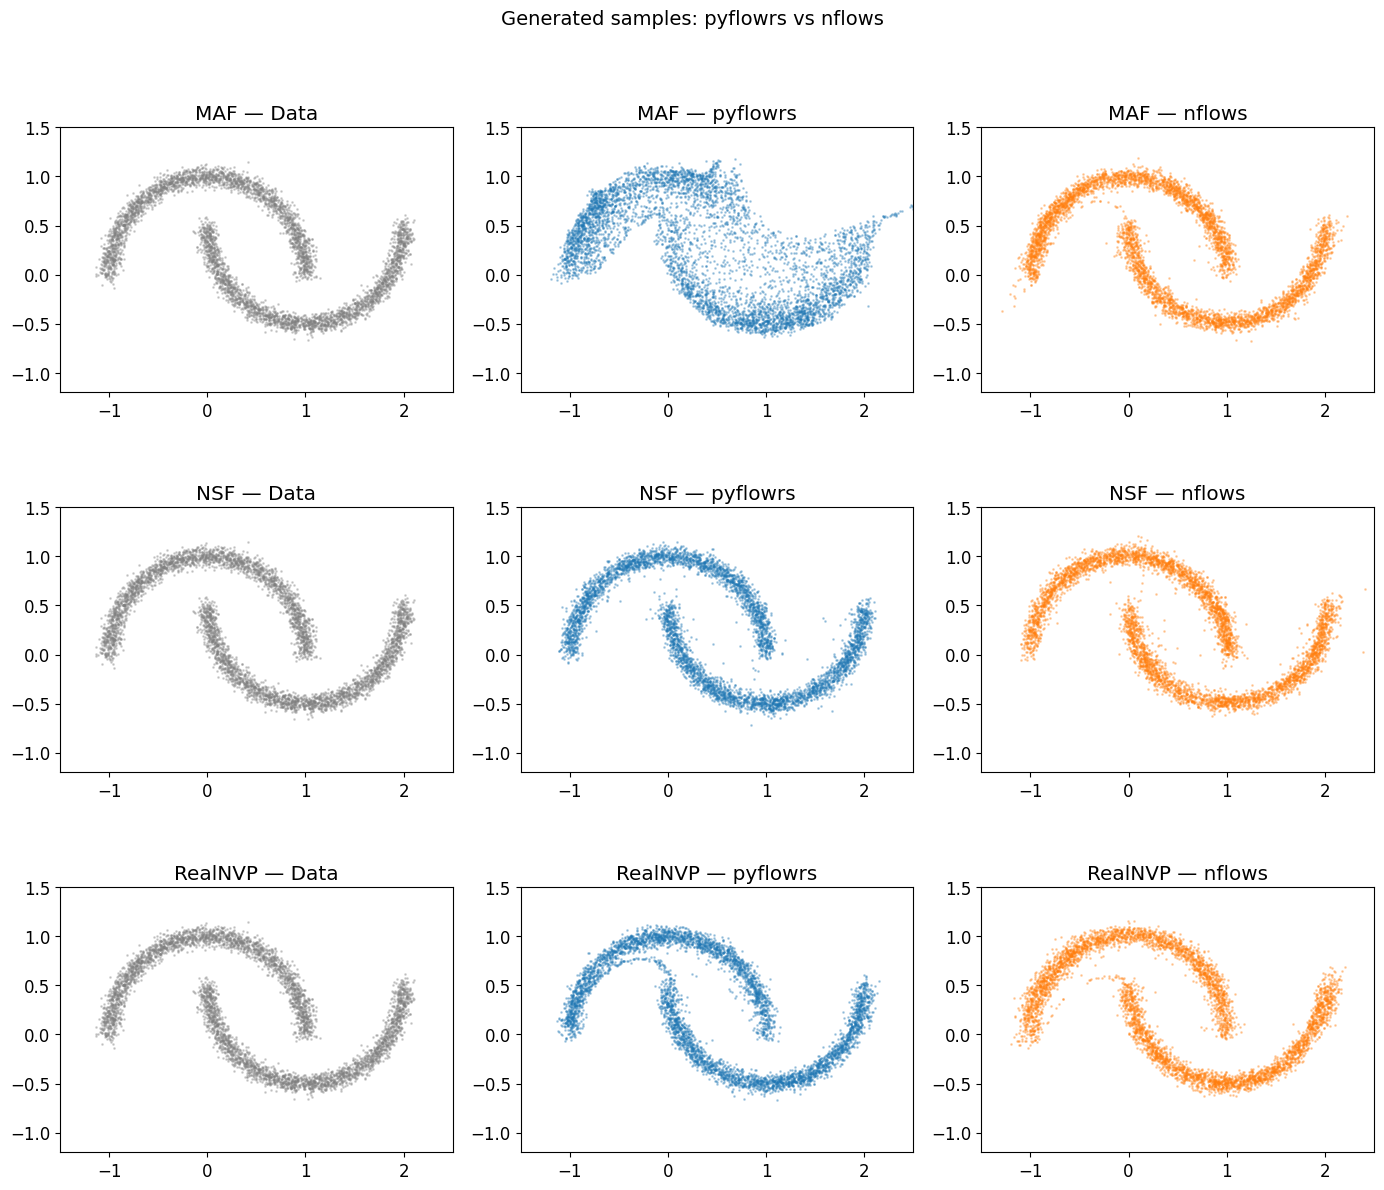

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for row, name in enumerate(configs):
    fr_s = flowrs_results[name]["samples"]
    nf_s = nflows_results[name]["samples"]

    # Ground truth
    axes[row, 0].scatter(train_data[:5000, 0], train_data[:5000, 1], s=1, alpha=0.3, c="gray")
    axes[row, 0].set_title(f"{name} — Data")

    # pyflowrs
    axes[row, 1].scatter(fr_s[:5000, 0], fr_s[:5000, 1], s=1, alpha=0.3, c="C0")
    axes[row, 1].set_title(f"{name} — pyflowrs")

    # nflows
    axes[row, 2].scatter(nf_s[:5000, 0], nf_s[:5000, 1], s=1, alpha=0.3, c="C1")
    axes[row, 2].set_title(f"{name} — nflows")

    for ax in axes[row]:
        ax.set_xlim(-1.5, 2.5)
        ax.set_ylim(-1.2, 1.5)
        ax.set_aspect("equal")

plt.suptitle("Generated samples: pyflowrs vs nflows", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Learned density (log-prob heatmap)

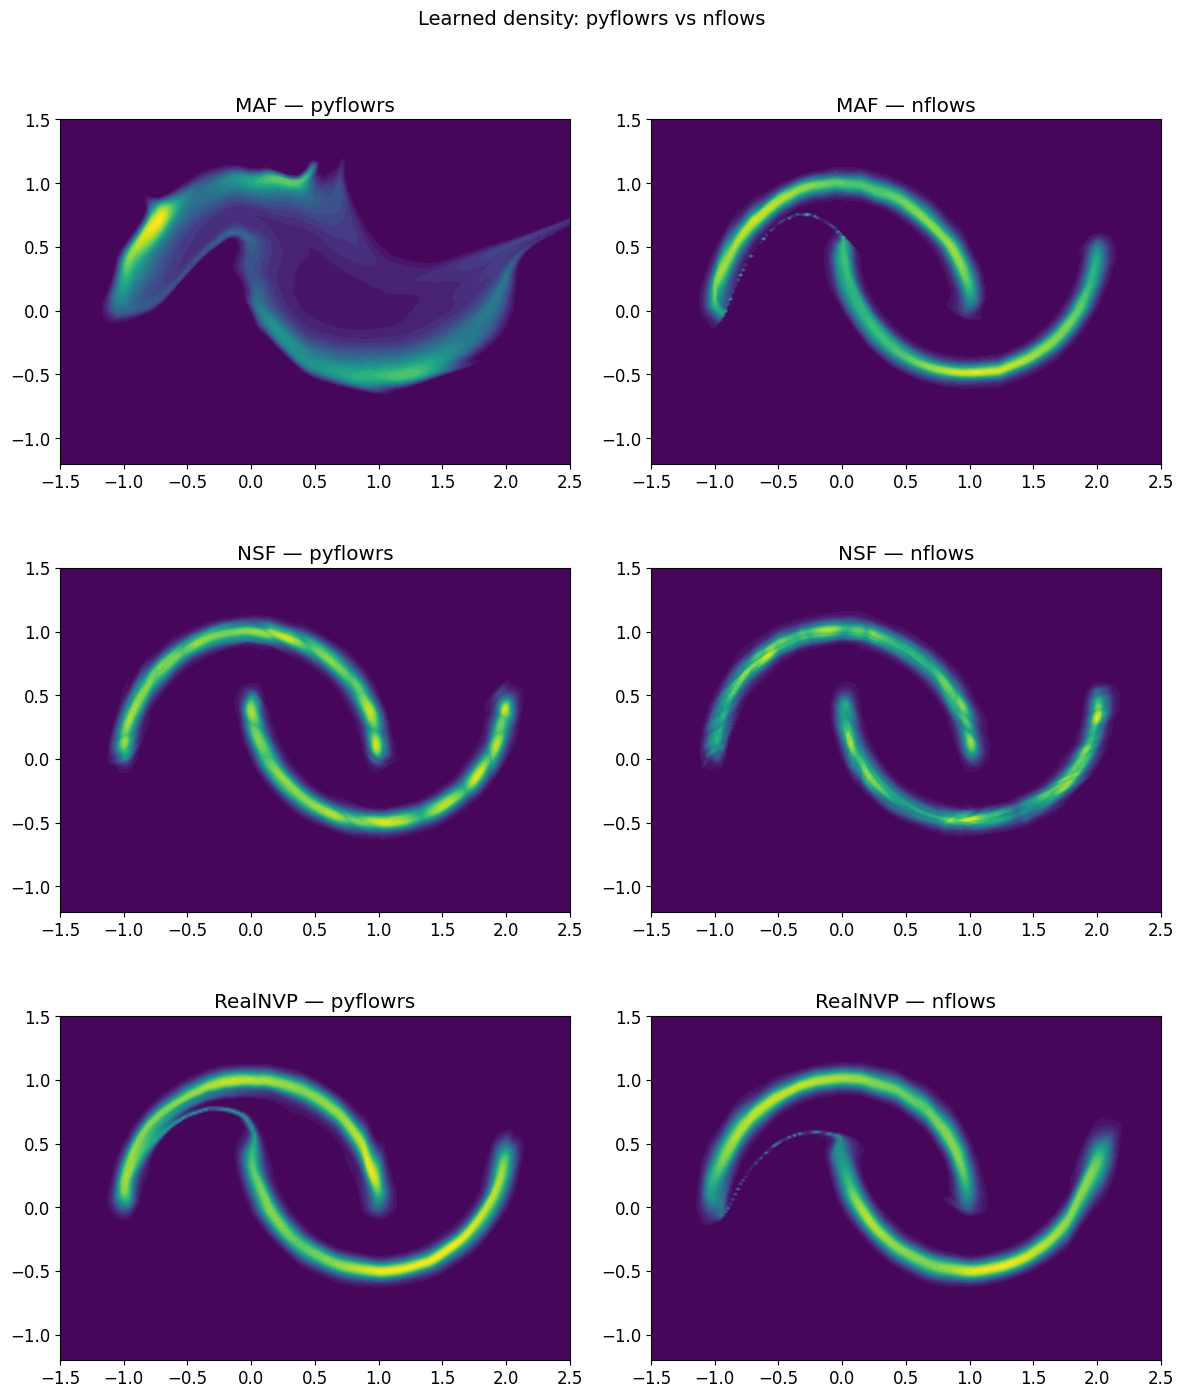

In [9]:
# Evaluate log-prob on a grid
grid_res = 200
xg = np.linspace(-1.5, 2.5, grid_res)
yg = np.linspace(-1.2, 1.5, grid_res)
xx, yy = np.meshgrid(xg, yg)
grid_pts = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

for row, name in enumerate(configs):
    # pyflowrs
    lp_fr = flowrs_results[name]["flow"].log_prob(grid_pts)
    lp_fr = lp_fr.reshape(grid_res, grid_res)
    axes[row, 0].contourf(xx, yy, np.exp(lp_fr), levels=30, cmap="viridis")
    axes[row, 0].set_title(f"{name} — pyflowrs")
    axes[row, 0].set_aspect("equal")

    # nflows
    with torch.no_grad():
        lp_nf = nflows_results[name]["model"].log_prob(
            torch.tensor(grid_pts)
        ).numpy().reshape(grid_res, grid_res)
    axes[row, 1].contourf(xx, yy, np.exp(lp_nf), levels=30, cmap="viridis")
    axes[row, 1].set_title(f"{name} — nflows")
    axes[row, 1].set_aspect("equal")

plt.suptitle("Learned density: pyflowrs vs nflows", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Timing bar chart

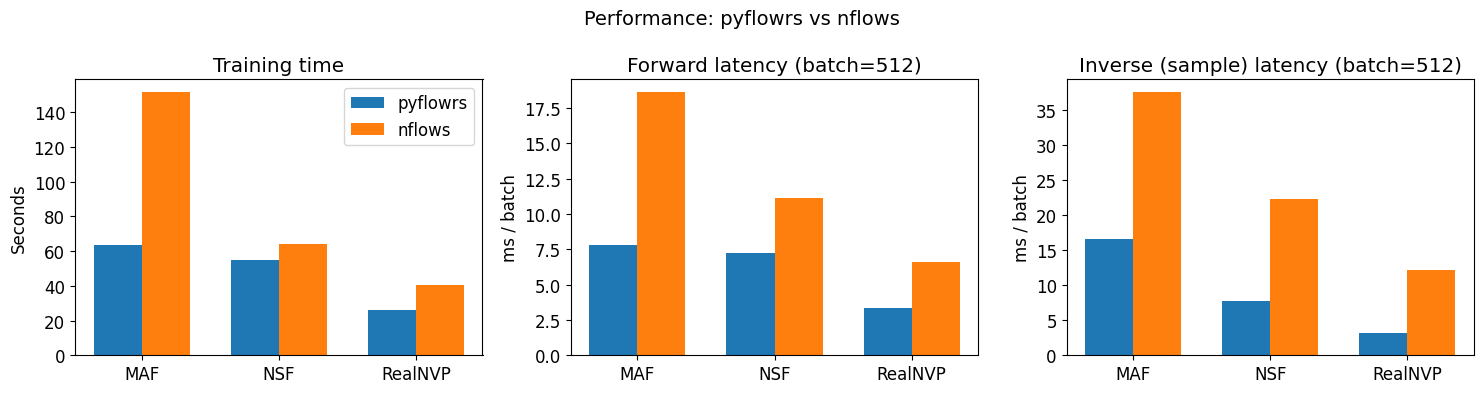

In [10]:
model_names = list(configs.keys())
x = np.arange(len(model_names))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train time
fr_times = [flowrs_results[n]["train_time"] for n in model_names]
nf_times = [nflows_results[n]["train_time"] for n in model_names]
axes[0].bar(x - w/2, fr_times, w, label="pyflowrs", color="C0")
axes[0].bar(x + w/2, nf_times, w, label="nflows", color="C1")
axes[0].set_ylabel("Seconds")
axes[0].set_title("Training time")
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].legend()

# Forward latency
fr_fwd = [flowrs_results[n]["fwd_ms"] for n in model_names]
nf_fwd = [nflows_results[n]["fwd_ms"] for n in model_names]
axes[1].bar(x - w/2, fr_fwd, w, label="pyflowrs", color="C0")
axes[1].bar(x + w/2, nf_fwd, w, label="nflows", color="C1")
axes[1].set_ylabel("ms / batch")
axes[1].set_title(f"Forward latency (batch={BATCH_SIZE})")
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)

# Inverse latency
fr_inv = [flowrs_results[n]["inv_ms"] for n in model_names]
nf_inv = [nflows_results[n]["inv_ms"] for n in model_names]
axes[2].bar(x - w/2, fr_inv, w, label="pyflowrs", color="C0")
axes[2].bar(x + w/2, nf_inv, w, label="nflows", color="C1")
axes[2].set_ylabel("ms / batch")
axes[2].set_title(f"Inverse (sample) latency (batch={BATCH_SIZE})")
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names)

plt.suptitle("Performance: pyflowrs vs nflows", fontsize=14)
plt.tight_layout()
plt.show()